<a href="https://colab.research.google.com/github/Gabriel-git24/cassava_leaf_disease_classification/blob/main/Copy_of_Capstone_project_1_v8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
import tensorflow as tf
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import mixed_precision
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.applications import ResNet50
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.utils import class_weight
import numpy as np
import pathlib

data_dir = "/content/drive/MyDrive/Capstone Project/archive (5)/split_dataset"
image_size = (512, 512)
batch_size = 32
num_epochs = 100

class_names = [
    "Cassava___bacterial_blight",
    "Cassava___brown_streak_disease",
    "Cassava___green_mottle",
    "Cassava___mosaic_disease",
    "Cassava___healthy"
]

num_classes = len(class_names)

mixed_precision.set_global_policy('mixed_float16')

def augment(image):
  image = tf.image.random_flip_left_right(image)
  image = tf.image.random_flip_up_down(image)
  return image

train_generator = tf.keras.utils.image_dataset_from_directory(
    f"{data_dir}/train",
    image_size=image_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=True
)

val_generator = tf.keras.utils.image_dataset_from_directory(
    f"{data_dir}/val",
    image_size=image_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=False
)

test_generator = tf.keras.utils.image_dataset_from_directory(
    f"{data_dir}/test",
    image_size=image_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE

#preprocssing first, then augmenting on training dataset only
train_generator = train_generator.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
train_generator = train_generator.map(lambda x, y: (augment(x), y), num_parallel_calls=AUTOTUNE)

#no augmentation for validation and test datasets
val_generator = val_generator.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
test_generator = test_generator.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)

Found 14975 files belonging to 5 classes.
Found 3207 files belonging to 5 classes.
Found 3215 files belonging to 5 classes.


In [18]:
def build_resnet_classifier_v1(input_shape=(512, 512, 3), num_classes=5, learning_rate=1e-6):

  base_model = ResNet50(
      weights = "imagenet",
      include_top = False,
      input_shape = input_shape
  )

  for layer in base_model.layers[:-10]:
    layer.trainable = False

  for layer in base_model.layers[:-10]:
    layer.trainable = False

  #defining architecture
  model = models.Sequential([
      #define the input shape
      layers.Input(shape=input_shape),
      base_model,
      layers.GlobalAveragePooling2D(),
      layers.Dense(256, activation="relu"),
      layers.Dropout(0.5),
      layers.Dense(num_classes, activation="softmax", dtype="float32")
  ])

  model.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
      loss="categorical_crossentropy",
      metrics=['accuracy']
  )

  return model

In [19]:
model = build_resnet_classifier_v1(input_shape=(512, 512, 3), num_classes=5)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 16, 16, 2048)   │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,541 (91.99 MB)

 Trainable params: 4,991,493 (19.04 MB)

 Non-trainable params: 19,122,048 (72.94 MB)

In [20]:
data_dir_train = f"{data_dir}/train"

# Get class names in alphabetical order (same as Keras)
class_names_sorted = sorted([d.name for d in pathlib.Path(data_dir_train).iterdir() if d.is_dir()])

# Count files per class
y_train = []
for idx, class_name in enumerate(class_names_sorted):
    class_path = pathlib.Path(data_dir_train) / class_name
    num_images = len(list(class_path.glob("*")))
    y_train.extend([idx] * num_images)

y_train = np.array(y_train)

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(weights))
print("Computed Class Weights:", class_weight_dict)

Computed Class Weights: {0: np.float64(3.9407894736842106), 1: np.float64(1.9549608355091384), 2: np.float64(1.7934131736526946), 3: np.float64(1.661120354963949), 4: np.float64(0.3251900108577633)}


In [21]:
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/Capstone Project/models/resnet_v1.keras",
    save_best_only=True,
    monitor="val_accuracy",
)

early_stopping = EarlyStopping(
   monitor='val_loss',
   patience=5,
   restore_best_weights=True,
   min_delta=0.001,
   verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_delta=0.001
)

# Start training
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=num_epochs,
    callbacks=[checkpoint, early_stopping, reduce_lr]
)

Epoch 1/100
468/468 ━━━━━━━━━━━━━━━━━━━━ 90s 155ms/step - accuracy: 0.3537 - loss: 1.7206 - val_accuracy: 0.6143 - val_loss: 1.2377 - learning_rate: 1.0000e-06
Epoch 2/100
468/468 ━━━━━━━━━━━━━━━━━━━━ 65s 137ms/step - accuracy: 0.5655 - loss: 1.3129 - val_accuracy: 0.6268 - val_loss: 1.0952 - learning_rate: 1.0000e-06
Epoch 3/100
468/468 ━━━━━━━━━━━━━━━━━━━━ 65s 136ms/step - accuracy: 0.6035 - loss: 1.1771 - val_accuracy: 0.6355 - val_loss: 0.9974 - learning_rate: 1.0000e-06
Epoch 4/100
468/468 ━━━━━━━━━━━━━━━━━━━━ 64s 136ms/step - accuracy: 0.6262 - loss: 1.0868 - val_accuracy: 0.6514 - val_loss: 0.9277 - learning_rate: 1.0000e-06
Epoch 5/100
468/468 ━━━━━━━━━━━━━━━━━━━━ 64s 135ms/step - accuracy: 0.6399 - loss: 1.0173 - val_accuracy: 0.6635 - val_loss: 0.8749 - learning_rate: 1.0000e-06
Epoch 6/100
468/468 ━━━━━━━━━━━━━━━━━━━━ 64s 135ms/step - accuracy: 0.6487 - loss: 0.9667 - val_accuracy: 0.6751 - val_loss: 0.8336 - learning_rate: 1.0000e-06
Epoch 7/100
468/468 ━━━━━━━━━━━━━━━━━━━━

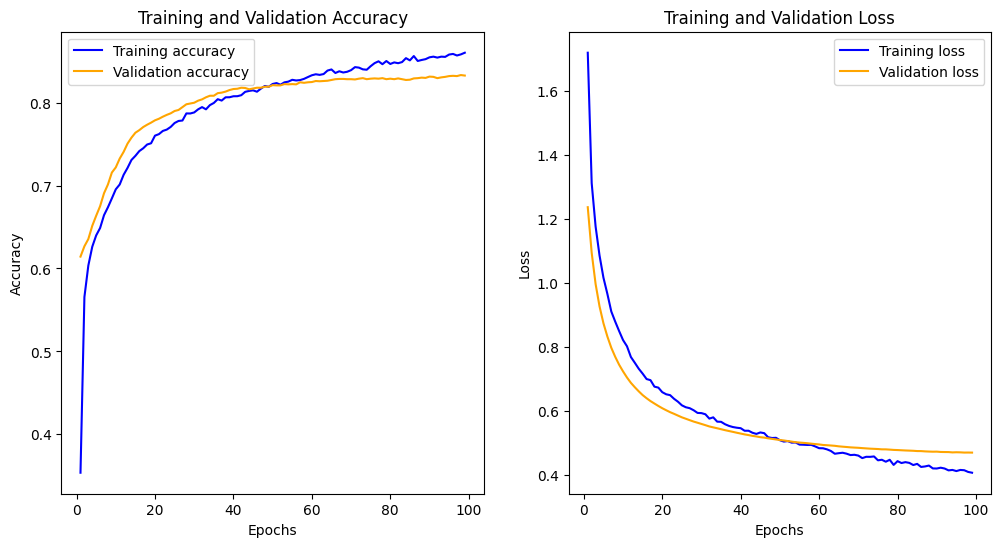

In [23]:
history_dict = history.history
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b', label='Training accuracy')
plt.plot(epochs, val_acc, 'orange', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'orange', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

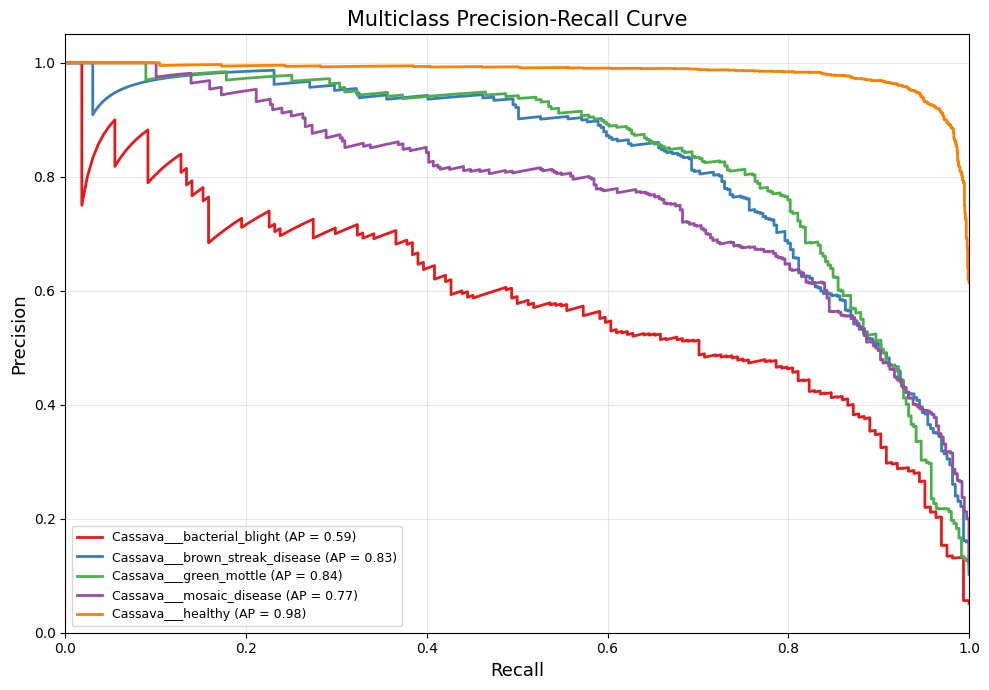

In [8]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Get predictions
y_true = []
y_pred = []

for images, labels in test_generator:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

for i, (class_name, color) in enumerate(zip(class_names, colors)):
    precision, recall, _ = precision_recall_curve(y_true[:, i], y_pred[:, i])
    ap = average_precision_score(y_true[:, i], y_pred[:, i])
    ax.plot(recall, precision, color=color, lw=2, label=f"{class_name} (AP = {ap:.2f})")

ax.set_xlabel("Recall", fontsize=13)
ax.set_ylabel("Precision", fontsize=13)
ax.set_title("Multiclass Precision-Recall Curve", fontsize=15)
ax.legend(loc="lower left", fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

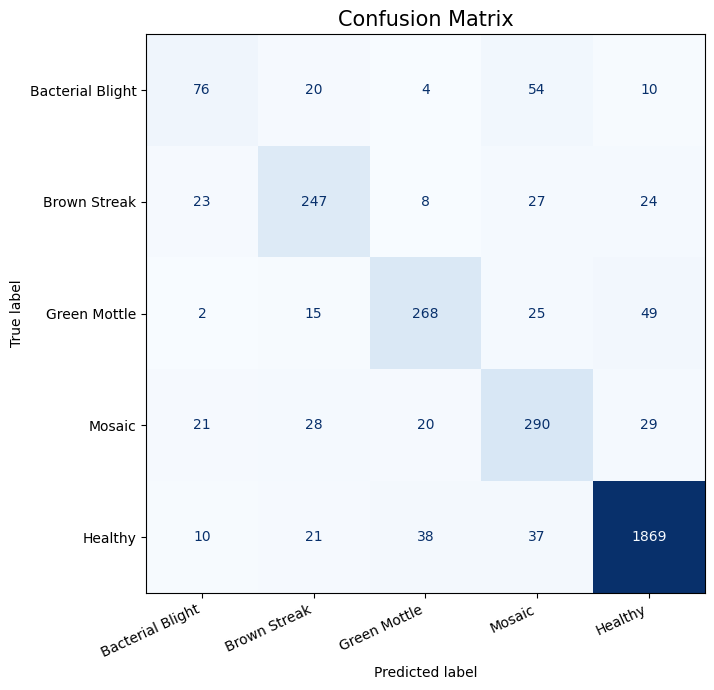


Per-class Accuracy:
  Bacterial Blight: 46.34%
  Brown Streak: 75.08%
  Green Mottle: 74.65%
  Mosaic: 74.74%
  Healthy: 94.63%


In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Reuse y_true and y_pred from above — just argmax them
y_true_labels = np.argmax(y_true, axis=1)
y_pred_labels = np.argmax(y_pred, axis=1)

short_names = [
    "Bacterial Blight",
    "Brown Streak",
    "Green Mottle",
    "Mosaic",
    "Healthy"
]

cm = confusion_matrix(y_true_labels, y_pred_labels)

fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=short_names)
disp.plot(ax=ax, cmap="Blues", colorbar=False)

plt.xticks(rotation=25, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.title("Confusion Matrix", fontsize=15)
plt.tight_layout()
plt.show()

# Per-class accuracy
print("\nPer-class Accuracy:")
for i, name in enumerate(short_names):
    class_acc = cm[i, i] / cm[i].sum()
    print(f"  {name}: {class_acc:.2%}")

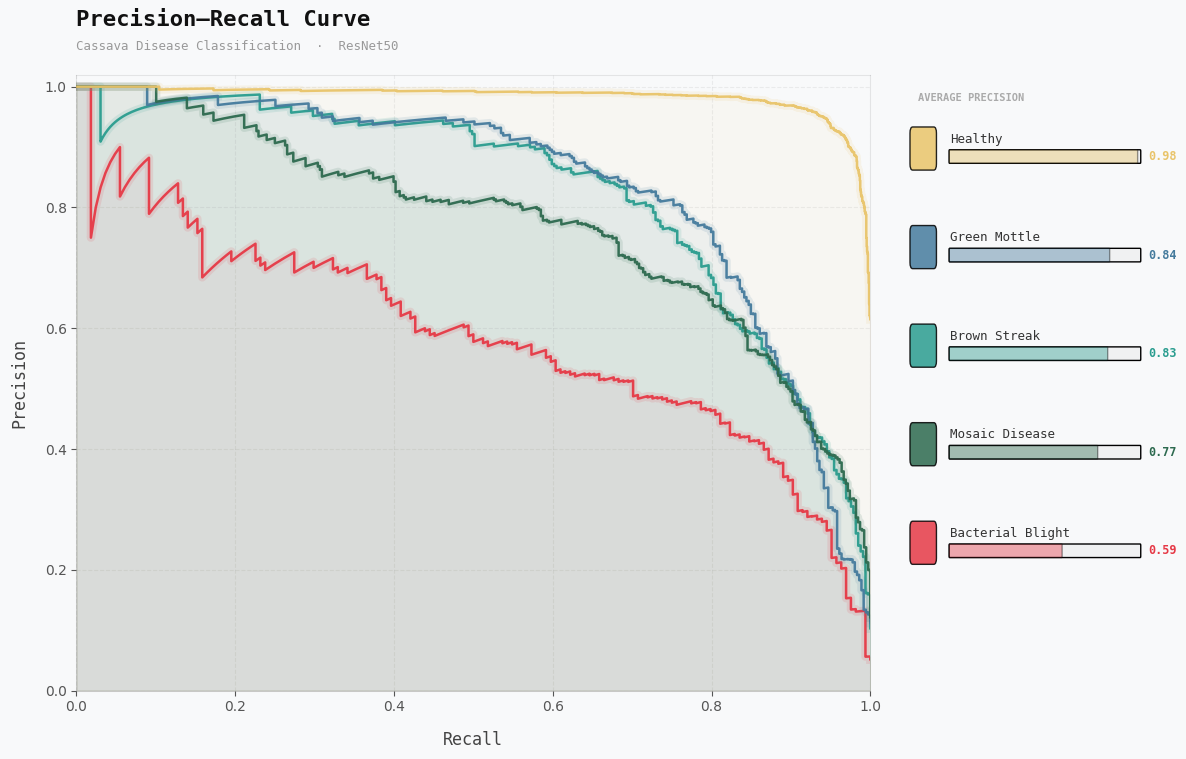

In [10]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import numpy as np

fig = plt.figure(figsize=(14, 8), facecolor='#F8F9FA')
gs = GridSpec(1, 2, width_ratios=[3, 1], wspace=0.05)
ax = fig.add_subplot(gs[0])
ax_legend = fig.add_subplot(gs[1])

ax.set_facecolor('#F8F9FA')
ax_legend.set_facecolor('#F8F9FA')
ax_legend.axis('off')

ax.grid(True, color='#000000', alpha=0.06, linewidth=0.8, linestyle='--')
ax.set_axisbelow(True)

colors = ['#E63946', '#2A9D8F', '#457B9D', '#2D6A4F', '#E9C46A']
short_names = ['Bacterial Blight', 'Brown Streak', 'Green Mottle', 'Mosaic Disease', 'Healthy']

legend_elements = []
for i, (name, color) in enumerate(zip(short_names, colors)):
    precision, recall, _ = precision_recall_curve(y_true[:, i], y_pred[:, i])
    ap = average_precision_score(y_true[:, i], y_pred[:, i])

    ax.plot(recall, precision, color=color, lw=6, alpha=0.12)
    ax.plot(recall, precision, color=color, lw=1.8, alpha=0.95, solid_capstyle='round')
    ax.fill_between(recall, precision, alpha=0.05, color=color)

    legend_elements.append((name, ap, color))

for spine in ax.spines.values():
    spine.set_color('#00000015')

ax.tick_params(colors='#555555', labelsize=10)
ax.set_xlabel('Recall', color='#444444', fontsize=12, labelpad=12, fontfamily='monospace')
ax.set_ylabel('Precision', color='#444444', fontsize=12, labelpad=12, fontfamily='monospace')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

# Change pad and loc on the title
ax.set_title('Precision–Recall Curve', color='#111111', fontsize=16,
             fontfamily='monospace', fontweight='bold', pad=35, loc='left')

# Move subtitle lower
ax.text(0, 1.04, 'Cassava Disease Classification  ·  ResNet50',
        transform=ax.transAxes, color='#999999', fontsize=9, fontfamily='monospace')

ax_legend.text(0.08, 0.97, 'AVERAGE PRECISION', color='#AAAAAA',
               fontsize=7.5, fontfamily='monospace', fontweight='bold',
               transform=ax_legend.transAxes, va='top')

legend_elements_sorted = sorted(legend_elements, key=lambda x: x[1], reverse=True)

for idx, (name, ap, color) in enumerate(legend_elements_sorted):
    y_pos = 0.88 - idx * 0.16

    rect = mpatches.FancyBboxPatch((0.06, y_pos - 0.025), 0.08, 0.05,
                                    boxstyle="round,pad=0.01",
                                    facecolor=color, alpha=0.85,
                                    transform=ax_legend.transAxes)
    ax_legend.add_patch(rect)

    ax_legend.text(0.2, y_pos + 0.015, name, color='#333333',
                   fontsize=9, fontfamily='monospace',
                   transform=ax_legend.transAxes, va='center')

    bar_x = 0.2
    bar_w = 0.72

    bar_bg = mpatches.FancyBboxPatch((bar_x, y_pos - 0.022), bar_w, 0.018,
                                      boxstyle="round,pad=0.002",
                                      facecolor='#00000008',
                                      transform=ax_legend.transAxes)
    ax_legend.add_patch(bar_bg)

    bar_fill = mpatches.FancyBboxPatch((bar_x, y_pos - 0.022), bar_w * ap, 0.018,
                                        boxstyle="round,pad=0.002",
                                        facecolor=color, alpha=0.4,
                                        transform=ax_legend.transAxes)
    ax_legend.add_patch(bar_fill)

    ax_legend.text(0.2 + bar_w + 0.03, y_pos - 0.013, f'{ap:.2f}',
                   color=color, fontsize=8.5, fontfamily='monospace',
                   fontweight='bold', transform=ax_legend.transAxes, va='center')

plt.savefig('pr_curve.png', dpi=180, bbox_inches='tight',
            facecolor='#F8F9FA', edgecolor='none')
plt.show()

In [11]:
from sklearn.metrics import classification_report

short_names = [
    "Bacterial Blight",
    "Brown Streak",
    "Green Mottle",
    "Mosaic Disease",
    "Healthy"
]

y_true_labels = np.argmax(y_true, axis=1)
y_pred_labels = np.argmax(y_pred, axis=1)

print(classification_report(y_true_labels, y_pred_labels, target_names=short_names))

                  precision    recall  f1-score   support

Bacterial Blight       0.58      0.46      0.51       164
    Brown Streak       0.75      0.75      0.75       329
    Green Mottle       0.79      0.75      0.77       359
  Mosaic Disease       0.67      0.75      0.71       388
         Healthy       0.94      0.95      0.94      1975

        accuracy                           0.86      3215
       macro avg       0.75      0.73      0.74      3215
    weighted avg       0.85      0.86      0.85      3215



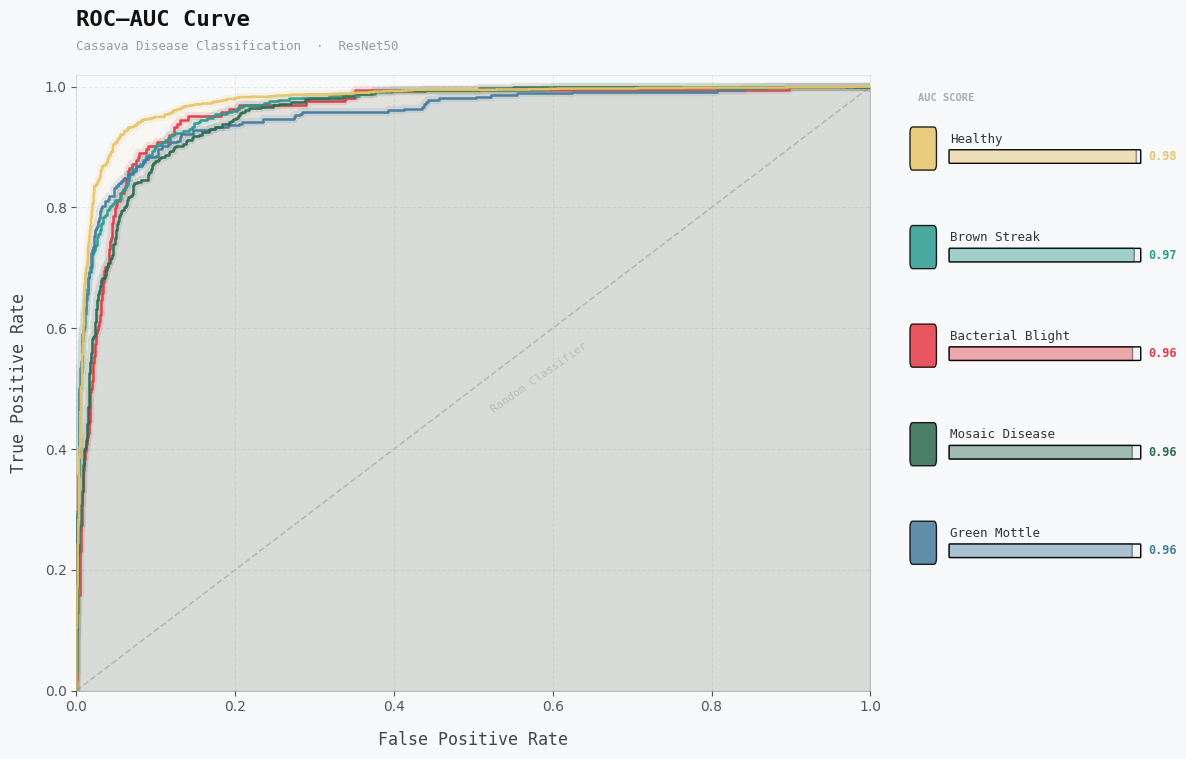

In [12]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import numpy as np

fig = plt.figure(figsize=(14, 8), facecolor='#F8F9FA')
gs = GridSpec(1, 2, width_ratios=[3, 1], wspace=0.05)
ax = fig.add_subplot(gs[0])
ax_legend = fig.add_subplot(gs[1])

ax.set_facecolor('#F8F9FA')
ax_legend.set_facecolor('#F8F9FA')
ax_legend.axis('off')

ax.grid(True, color='#000000', alpha=0.06, linewidth=0.8, linestyle='--')
ax.set_axisbelow(True)

# Random classifier baseline
ax.plot([0, 1], [0, 1], color='#CCCCCC', lw=1.2, linestyle='--', zorder=1)
ax.text(0.52, 0.46, 'Random Classifier', color='#BBBBBB', fontsize=8, fontfamily='monospace', rotation=35)

colors = ['#E63946', '#2A9D8F', '#457B9D', '#2D6A4F', '#E9C46A']
short_names = ['Bacterial Blight', 'Brown Streak', 'Green Mottle', 'Mosaic Disease', 'Healthy']

legend_elements = []
for i, (name, color) in enumerate(zip(short_names, colors)):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, color=color, lw=6, alpha=0.12)
    ax.plot(fpr, tpr, color=color, lw=1.8, alpha=0.95, solid_capstyle='round')
    ax.fill_between(fpr, tpr, alpha=0.05, color=color)

    legend_elements.append((name, roc_auc, color))

for spine in ax.spines.values():
    spine.set_color('#00000015')

ax.tick_params(colors='#555555', labelsize=10)
ax.set_xlabel('False Positive Rate', color='#444444', fontsize=12, labelpad=12, fontfamily='monospace')
ax.set_ylabel('True Positive Rate', color='#444444', fontsize=12, labelpad=12, fontfamily='monospace')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

ax.set_title('ROC–AUC Curve', color='#111111', fontsize=16,
             fontfamily='monospace', fontweight='bold', pad=35, loc='left')
ax.text(0, 1.04, 'Cassava Disease Classification  ·  ResNet50',
        transform=ax.transAxes, color='#999999', fontsize=9, fontfamily='monospace')

ax_legend.text(0.08, 0.97, 'AUC SCORE', color='#AAAAAA',
               fontsize=7.5, fontfamily='monospace', fontweight='bold',
               transform=ax_legend.transAxes, va='top')

legend_elements_sorted = sorted(legend_elements, key=lambda x: x[1], reverse=True)

for idx, (name, roc_auc, color) in enumerate(legend_elements_sorted):
    y_pos = 0.88 - idx * 0.16

    rect = mpatches.FancyBboxPatch((0.06, y_pos - 0.025), 0.08, 0.05,
                                    boxstyle="round,pad=0.01",
                                    facecolor=color, alpha=0.85,
                                    transform=ax_legend.transAxes)
    ax_legend.add_patch(rect)

    ax_legend.text(0.2, y_pos + 0.015, name, color='#333333',
                   fontsize=9, fontfamily='monospace',
                   transform=ax_legend.transAxes, va='center')

    bar_x = 0.2
    bar_w = 0.72

    bar_bg = mpatches.FancyBboxPatch((bar_x, y_pos - 0.022), bar_w, 0.018,
                                      boxstyle="round,pad=0.002",
                                      facecolor='#00000008',
                                      transform=ax_legend.transAxes)
    ax_legend.add_patch(bar_bg)

    bar_fill = mpatches.FancyBboxPatch((bar_x, y_pos - 0.022), bar_w * roc_auc, 0.018,
                                        boxstyle="round,pad=0.002",
                                        facecolor=color, alpha=0.4,
                                        transform=ax_legend.transAxes)
    ax_legend.add_patch(bar_fill)

    ax_legend.text(0.2 + bar_w + 0.03, y_pos - 0.013, f'{roc_auc:.2f}',
                   color=color, fontsize=8.5, fontfamily='monospace',
                   fontweight='bold', transform=ax_legend.transAxes, va='center')

plt.savefig('roc_auc_curve.png', dpi=180, bbox_inches='tight',
            facecolor='#F8F9FA', edgecolor='none')
plt.show()

In [13]:
from google.colab import files
files.download('roc_auc_curve.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

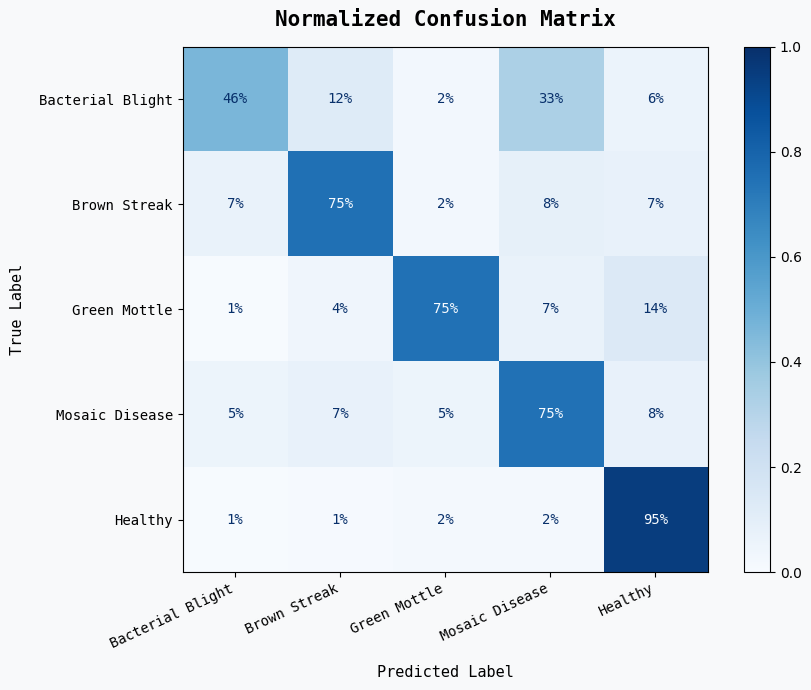

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

short_names = [
    "Bacterial Blight",
    "Brown Streak",
    "Green Mottle",
    "Mosaic Disease",
    "Healthy"
]

y_true_labels = np.argmax(y_true, axis=1)
y_pred_labels = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_true_labels, y_pred_labels, normalize='true')

fig, ax = plt.subplots(figsize=(9, 7), facecolor='#F8F9FA')
ax.set_facecolor('#F8F9FA')

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=short_names)
disp.plot(ax=ax, cmap='Blues', colorbar=False)

plt.colorbar(disp.im_, ax=ax)
# Fix the color scale after plotting
disp.im_.set_clim(0, 1)


# Style the numbers as percentages
for text in disp.text_.ravel():
    text.set_text(f"{float(text.get_text()):.0%}")
    text.set_fontsize(10)
    text.set_fontfamily('monospace')

plt.xticks(rotation=25, ha='right', fontsize=10, fontfamily='monospace')
plt.yticks(fontsize=10, fontfamily='monospace')
ax.set_title('Normalized Confusion Matrix', fontsize=15,
             fontfamily='monospace', fontweight='bold', pad=15)
ax.set_xlabel('Predicted Label', fontsize=11, fontfamily='monospace', labelpad=10)
ax.set_ylabel('True Label', fontsize=11, fontfamily='monospace', labelpad=10)

plt.tight_layout()
plt.savefig('normalized_cm.png', dpi=180, bbox_inches='tight',
            facecolor='#F8F9FA', edgecolor='none')
plt.show()

In [15]:
from google.colab import files
files.download('normalized_cm.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>